In [1]:
from pytential.sympy_pytential import sympy_pytential
from pytential.reduce import min_pytential
import numpy as np
from sympy import log, symbols
import matplotlib.pyplot as plt

This file demonstrates how to create, combine, and manipulate pytentials.  Equibilriation is used to reduce free variables. 

# Create phases

Create two binary ideal solutions

In [2]:
c0a, c1a, c0b, c1b = symbols('c0a, c1a, c0b, c1b')

In [3]:
RT = 8.134*300
fa_sp = c0a*RT*(1+log(c0a/(c0a+c1a))) +c1a*RT*(0+log(c1a/(c0a+c1a)))
fb_sp = c0b*RT*(0+log(c0b/(c0b+c1b))) +c1b*RT*(1+log(c1b/(c0b+c1b)))

In [4]:
fa = sympy_pytential(fa_sp, constraints_sym=[c0a+c1a-.5])
fb = sympy_pytential(fb_sp, constraints_sym=[c0b+c1b-.5])
print('fa:', fa)

fa: x = ['c0a', 'c1a']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c1a*log(c1a/(c0a + c1a))

f'(x)= [2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c1a/(c0a + c1a))]

f"(x)= [[2440.2*c1a/(c0a*(c0a + c1a)), -2440.2/(c0a + c1a)], [-2440.2/(c0a + c1a), 2440.2*c0a/(c1a*(c0a + c1a))]]

Constraints:
0 = c0a + c1a - 0.5



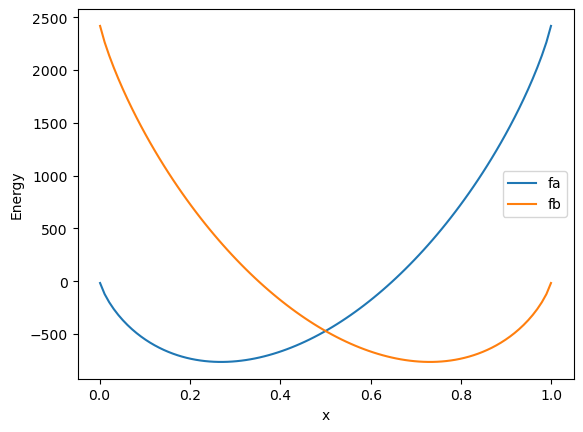

In [5]:
x_values = np.linspace(0.001, .999, 100)
ya = fa(c0a=x_values, c1a=1-x_values)
yb = fb(c0b=x_values, c1b=1-x_values)

plt.plot(x_values, ya, label='fa')
plt.plot(x_values, yb, label='fb')
plt.xlabel('x')
plt.ylabel('Energy')
plt.legend()
plt.show()

# Combine functions

Combine functions into a composite pytential

In [6]:
f = fa+fb
print(f)

x = ['c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[2440.2*c1a/(c0a*(c0a + c1a)), 0, -2440.2/(c0a + c1a), 0], [0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, -2440.2/(c0b + c1b)], [-2440.2/(c0a + c1a), 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, -2440.2/(c0b + c1b), 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = c0a + c1a - 0.5
c0b + c1b - 0.5



Add a constraint for the total x. Note the function is now an argument of x1, x2, and x

In [7]:
c0, c1 = symbols('c0, c1')
f_constrained = f.add_constraints_sym([c0a+c0b-c0, c1a+c1b-c1]) 
print(f_constrained)

x = ['c0', 'c0a', 'c0b', 'c1', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [0, 2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 0, 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[0, 0, 0, 0, 0, 0], [0, 2440.2*c1a/(c0a*(c0a + c1a)), 0, 0, -2440.2/(c0a + c1a), 0], [0, 0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, 0, -2440.2/(c0b + c1b)], [0, 0, 0, 0, 0, 0], [0, -2440.2/(c0a + c1a), 0, 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, 0, -2440.2/(c0b + c1b), 0, 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = c0a + c1a - 0.5
c0b + c1b - 0.5
-c0 + c0a + c0b
-c1 + c1a + c1b



In [8]:
f_r = f_constrained.set_variables({'c0':0.5, 'c1':0.5})
print(f_r.constraints_sym)

[c0a + c1a - 0.5, c0b + c1b - 0.5, c0a + c0b - 0.5, c1a + c1b - 0.5]


In [9]:
f_min = min_pytential(f_constrained, ['c0', 'c1'])
x_values = np.linspace(0.001, .999, 10)
print(f_min.min_fcn([.1,.9]))

pyt_reduced x = ['c0a', 'c0b', 'c1a', 'c1b']

f(x) = 2440.2*c0a*(log(c0a/(c0a + c1a)) + 1) + 2440.2*c0b*log(c0b/(c0b + c1b)) + 2440.2*c1a*log(c1a/(c0a + c1a)) + 2440.2*c1b*(log(c1b/(c0b + c1b)) + 1)

f'(x)= [2440.2*log(c0a/(c0a + c1a)) + 2440.2, 2440.2*log(c0b/(c0b + c1b)), 2440.2*log(c1a/(c0a + c1a)), 2440.2*log(c1b/(c0b + c1b)) + 2440.2]

f"(x)= [[2440.2*c1a/(c0a*(c0a + c1a)), 0, -2440.2/(c0a + c1a), 0], [0, 2440.2*c1b/(c0b*(c0b + c1b)), 0, -2440.2/(c0b + c1b)], [-2440.2/(c0a + c1a), 0, 2440.2*c0a/(c1a*(c0a + c1a)), 0], [0, -2440.2/(c0b + c1b), 0, 2440.2*c0b/(c1b*(c0b + c1b))]]

Constraints:
0 = c0a + c1a - 0.5
c0b + c1b - 0.5
c0a + c0b - 0.1
c1a + c1b - 0.9

[0.05]


/home/wellandm/Documents/GitHub/pytential/pytential/reduce/minimizer_tools.py:39: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  x0 = np.linalg.lstsq(A,-b)[0][0]


ValueError: not enough values to unpack (expected 4, got 1)

In [ ]:
from pytential.reduce.matrix_methods import get_constraints_matrix_and_vector
A, b = get_constraints_matrix_and_vector(f_r.constraints, 4)
import scipy as sp
np.linalg.lstsq(A, -b)